In [ ]:
pip install keras-tuner

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 KB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Trans-Ubiquitination-Colab/BraveHeart

/content/drive/MyDrive/Trans-Ubiquitination-Colab/BraveHeart


In [ ]:
import numpy as np
x = np.load("homo_gly_embeddings_X.npy")

In [ ]:
x.shape

(6684, 17664)

In [ ]:
y = np.load("homo_gly_embeddings_Y.npy")

In [ ]:
y.shape

(6684,)

In [ ]:
import pandas as pd
x_dataframe = pd.DataFrame(x)

In [ ]:
x_dataframe

,0,1,2,3,4,5,6,7,8,9,...,17654,17655,17656,17657,17658,17659,17660,17661,17662,17663
0,-0.670064,-0.205453,-0.162788,0.238185,-0.497634,0.001058,0.498252,0.217543,-0.204923,-0.193458,...,0.058214,-0.014467,-0.196105,-0.225642,0.041844,-0.069661,-0.033239,0.054932,-0.228640,-0.068469
1,0.148248,0.410427,-0.160469,-0.907297,-0.426901,-0.446572,0.441898,-0.929678,-0.320961,-0.327232,...,-0.008504,-0.048857,-0.160131,0.005937,0.464745,-0.093560,-0.289759,0.168618,-0.303013,0.615383
2,-0.672000,-0.157473,-0.155070,-0.118049,-0.484512,-0.128078,0.507044,0.094098,-0.129200,-0.446905,...,0.039919,0.031626,-0.210442,-0.186345,0.045548,-0.049786,0.021884,0.049393,-0.225488,-0.053107
3,-0.132867,0.849208,-0.978939,-1.040755,-1.157435,-0.268314,0.898318,-0.550852,-0.409919,0.014149,...,-0.099752,0.204240,0.072771,-0.050610,1.097281,-0.049464,-0.439880,0.144016,-0.291581,0.844872
4,-0.873999,-0.313660,-0.237740,-0.002625,-0.309743,-0.102321,0.587243,0.325927,-0.265885,-0.335534,...,0.081942,0.022739,-0.189747,-0.220977,0.046227,-0.086532,-0.019842,0.043630,-0.247233,-0.055414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6679,0.170743,0.856997,-1.132284,-1.372333,-0.804080,-0.158089,0.788468,-0.143002,0.390288,-0.043355,...,-0.203046,0.406106,0.083288,-0.140104,0.904826,-0.279064,-0.489204,0.250356,0.116384,0.886395
6680,-0.569732,-0.155709,-0.136024,-0.149933,-0.446000,-0.081807,0.493711,0.192582,-0.186166,-0.485428,...,0.033619,0.008939,-0.172864,-0.249434,0.026223,-0.062253,-0.006292,0.037104,-0.267372,-0.058867
6681,0.278941,0.867220,-0.684302,-0.722783,-1.062452,-0.475852,1.015704,0.254639,-0.553932,-0.933954,...,0.177753,0.125788,0.013824,0.191988,0.426629,-0.601371,-0.308372,-0.044944,0.065832,0.249223
6682,-0.824142,-0.163899,-0.147529,0.011811,-0.260180,-0.011521,0.452661,0.303969,-0.217640,-0.423763,...,0.083240,0.032962,-0.220289,-0.211165,0.047671,-0.052222,0.028940,0.060261,-0.230897,-0.042840


In [ ]:
y

array([1, 1, 1, ..., 0, 0, 0])

# 1D CNN

In [ ]:
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Activation, Conv1D, ZeroPadding1D, MaxPooling1D, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras import utils
import tensorflow as tf
from tensorflow import keras
from kerastuner import RandomSearch
from tensorflow.keras import utils
from sklearn.metrics import precision_recall_curve


xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.20, random_state = 42)
xval, xtest, yval, ytest = train_test_split(xtest, ytest, test_size = 0.5)

def CNN_1D():
    model = Sequential()

    # layer 1
    model.add(Conv1D(8, 4, input_shape=(23*768, 1), activation="relu"))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.1))

    # layer 2
    model.add(Conv1D(8, 2, activation="relu"))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.2))

    # Flattening Layer:
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))

    # Last Layer:
    model.add(Dense(2, activation="softmax"))
    model.compile(loss="categorical_crossentropy", optimizer=Adam(lr = 0.00005),
                  metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

model1 = CNN_1D()

a = np.asarray(xtrain).reshape(len(np.asarray(xtrain)),23*768,1)

history1_ = model1.fit(np.asarray(xtrain).reshape(len(np.asarray(xtrain)),23*768,1), utils.to_categorical(ytrain,2),
                    validation_data=(np.asarray(xval).reshape(len(np.asarray(xval)),23*768,1), utils.to_categorical(yval,2)),
                    epochs=50, batch_size=20, verbose=1)  

score = model1.evaluate(np.asarray(xtest).reshape(len(np.asarray(xtest)),23*768,1), utils.to_categorical(ytest,2), verbose=1)
print("categorical_crossentropy loss, Accuracy, Precision, Recall scores:", score)


plt.plot(history1_.history["accuracy"])
plt.plot(history1_.history["val_accuracy"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("True positive rate", fontsize = 15)
plt.title("1D CNN Model Accuracy", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()
plt.figure(figsize=(10,10), dpi = 600)

plt.plot(history1_.history["loss"])
plt.plot(history1_.history["val_loss"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("Loss", fontsize = 15)
plt.title("1D CNN Model Loss", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()

print(model1.summary())

import seaborn as sns
from sklearn.metrics import confusion_matrix
cnn_predictions1 = model1.predict(xtest)
bert2_probs_cnn1 = cnn_predictions1[:,1]
cnn_predictions1 = np.argmax(cnn_predictions1, axis = 1)
confusion_matrix = confusion_matrix(ytest, cnn_predictions1)
sns.heatmap(confusion_matrix, annot = True, fmt = "d", cbar = False)
plt.title("BERT + 1D CNN Confusion Matrix", fontsize = 20)
plt.show()


from sklearn.metrics import roc_curve
fpr_keras_bert_cnn1_hyp, tpr_keras_bert_cnn1_hyp, _ = roc_curve(ytest, bert2_probs_cnn1)

from sklearn.metrics import auc
auc_keras_bert_cnn1_hyp = auc(fpr_keras_bert_cnn1_hyp, tpr_keras_bert_cnn1_hyp)
print("AUC Score", auc_keras_bert_cnn1_hyp)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras_bert_cnn1_hyp, tpr_keras_bert_cnn1_hyp, label="BERT + 1D-CNN: {:.3f}".format(auc_keras_bert_cnn1_hyp))
plt.xlabel("False positive rate", fontsize = 15)
plt.ylabel("True positive rate", fontsize = 15)
plt.title("ROC curve for BERT + 1D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()

print("----------------------------------------------")


precision_bert2_cnn1, recall_bert2_cnn1, _ = precision_recall_curve(ytest, bert2_probs_cnn1)
auc_precision_recall_bert2_cnn1 = auc(recall_bert2_cnn1, precision_bert2_cnn1)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(recall_bert2_cnn1, precision_bert2_cnn1, label="BERT + 1D-CNN: {:.3f}".format(auc_precision_recall_bert2_cnn1))
plt.xlabel("Recall", fontsize = 15)
plt.ylabel("Precision", fontsize = 15)
plt.title("PR curve for BERT + 1D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()


print("----------------------------------------------")

# 2D CNN Without Tuner

In [ ]:
################ Without tuner ########################
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Activation, MaxPooling1D, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras import utils
import tensorflow as tf
from tensorflow import keras
from kerastuner import RandomSearch
from tensorflow.keras import utils
from sklearn.metrics import precision_recall_curve



xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.20, random_state=None, shuffle=True)
xval, xtest, yval, ytest = train_test_split(xtest, ytest, test_size = 0.5, random_state=None, shuffle=True)

def CNN_2D():
    model = Sequential()

    # layer 1
    model.add(Conv2D(32, 4, 4, input_shape=(768, 23, 1), activation="relu")) 
    model.add(MaxPooling2D(2))
    model.add(Dropout(0.1))


    # layer 2
    model.add(Conv2D(16, 2, 2, activation="relu"))
    #model.add(MaxPooling2D(2))
    model.add(Dropout(0.2))

    

    # Flattening Layer:
    model.add(Flatten())
    model.add(Dense(96, activation="relu"))
    model.add(Dense(32, activation="relu"))

    # Last Layer:
    model.add(Dense(2, activation="softmax"))
    model.compile(loss="binary_crossentropy", optimizer=Adam(lr = 0.00002),
                  metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

model2 = CNN_2D()

stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0.0008, patience=40,  verbose=1, mode='min')

history2_ = model2.fit(np.asarray(xtrain).reshape(len(np.asarray(xtrain)),768,23,1), utils.to_categorical(ytrain,2),
                    validation_data=(np.asarray(xval).reshape(len(np.asarray(xval)),768,23,1), utils.to_categorical(yval,2)), callbacks = [stop_early],
                    epochs=200, batch_size=150, verbose=1)


/usr/local/lib/python3.8/dist-packages/keras/optimizers/optimizer_v2/adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


Epoch 1/200
36/36 [==============================] - 1s 18ms/step - loss: 0.6958 - accuracy: 0.4978 - precision_17: 0.4978 - recall_17: 0.4978 - val_loss: 0.6944 - val_accuracy: 0.5150 - val_precision_17: 0.5150 - val_recall_17: 0.5150
Epoch 2/200
36/36 [==============================] - 0s 8ms/step - loss: 0.6953 - accuracy: 0.4967 - precision_17: 0.4967 - recall_17: 0.4967 - val_loss: 0.6939 - val_accuracy: 0.5180 - val_precision_17: 0.5180 - val_recall_17: 0.5180
Epoch 3/200
36/36 [==============================] - 0s 8ms/step - loss: 0.6948 - accuracy: 0.5057 - precision_17: 0.5057 - recall_17: 0.5057 - val_loss: 0.6937 - val_accuracy: 0.5090 - val_precision_17: 0.5090 - val_recall_17: 0.5090
Epoch 4/200
36/36 [==============================] - 0s 8ms/step - loss: 0.6942 - accuracy: 0.5096 - precision_17: 0.5096 - recall_17: 0.5096 - val_loss: 0.6935 - val_accuracy: 0.5090 - val_precision_17: 0.5090 - val_recall_17: 0.5090
Epoch 5/200
36/36 [==============================] - 0s 8ms

In [ ]:
model2.evaluate(np.asarray(xtest).reshape(len(np.asarray(xtest)),768,23,1), utils.to_categorical(ytest,2))

21/21 [==============================] - 0s 4ms/step - loss: 0.6687 - accuracy: 0.6129 - precision_17: 0.6129 - recall_17: 0.6129


[0.6687267422676086,
 0.6128550171852112,
 0.6128550171852112,
 0.6128550171852112]

---BERT + 2D CNN + Hyperparameter Tuning Accuracy plot was saved.


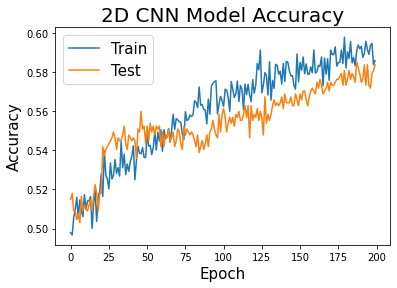

---BERT + 2D CNN + Hyperparameter Tuning Loss plot was saved.


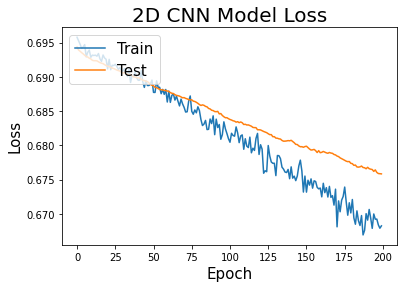

Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_22 (Conv2D)          (None, 192, 5, 32)        544       
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 96, 2, 32)        0         
 g2D)                                                            
                                                                 
 dropout_34 (Dropout)        (None, 96, 2, 32)         0         
                                                                 
 conv2d_23 (Conv2D)          (None, 48, 1, 16)         2064      
                                                                 
 dropout_35 (Dropout)        (None, 48, 1, 16)         0         
                                                                 
 flatten_17 (Flatten)        (None, 768)               0         
                                                     

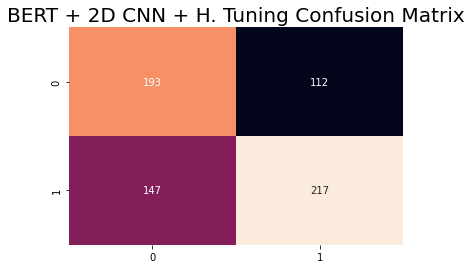

--- BERT + 2D CNN + Hyperparameter Tuning confusion matrix plot was saved.
AUC Score 0.636642046478112


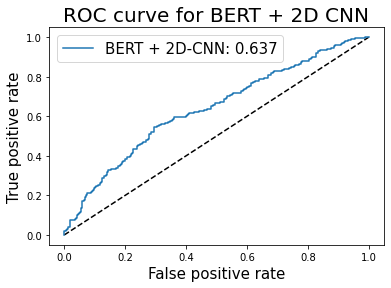

---BERT + 2D CNN + Hyperparameter Tuning ROC Curve plot was saved.


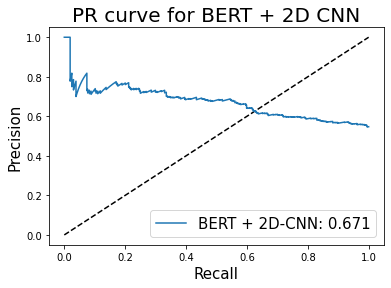

---BERT + 2D CNN + Hyperparameter Tuning PR Curve plot was saved.
----------------------------------------------


In [ ]:
plt.clf()
plt.plot(history2_.history["accuracy"])
plt.plot(history2_.history["val_accuracy"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("Accuracy", fontsize = 15)
plt.title("2D CNN Model Accuracy", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()


plt.clf()
plt.plot(history2_.history["loss"])
plt.plot(history2_.history["val_loss"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("Loss", fontsize = 15)
plt.title("2D CNN Model Loss", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()


print(model2.summary())

plt.clf()
import seaborn as sns
from sklearn.metrics import confusion_matrix
cnn_predictions3 = model2.predict(np.asarray(xtest).reshape(len(np.asarray(xtest)),768,23,1))
bert2_probs = cnn_predictions3[:,1]
print(cnn_predictions3[:,1])    
cnn_predictions3 = np.argmax(cnn_predictions3, axis = 1)
print(cnn_predictions3)
confusion_matrix = confusion_matrix(ytest, cnn_predictions3)
sns.heatmap(confusion_matrix, annot = True, fmt = "d", cbar = False)
plt.title("BERT + 2D CNN + H. Tuning Confusion Matrix", fontsize = 20)
plt.show()


from sklearn.metrics import roc_curve
fpr_keras_bert_cnn2_hyp, tpr_keras_bert_cnn2_hyp, thresholds_keras = roc_curve(ytest, bert2_probs)

from sklearn.metrics import auc
auc_keras_bert_cnn2_hyp = auc(fpr_keras_bert_cnn2_hyp, tpr_keras_bert_cnn2_hyp)
print("AUC Score", auc_keras_bert_cnn2_hyp)

plt.clf()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras_bert_cnn2_hyp, tpr_keras_bert_cnn2_hyp, label="BERT + 2D-CNN: {:.3f}".format(auc_keras_bert_cnn2_hyp))
plt.xlabel("False positive rate", fontsize = 15)
plt.ylabel("True positive rate", fontsize = 15)
plt.title("ROC curve for BERT + 2D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()


precision_bert2, recall_bert2, _ = precision_recall_curve(ytest, bert2_probs)
auc_precision_recall_bert2 = auc(recall_bert2, precision_bert2)

plt.clf()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(recall_bert2, precision_bert2, label="BERT + 2D-CNN: {:.3f}".format(auc_precision_recall_bert2))
plt.xlabel("Recall", fontsize = 15)
plt.ylabel("Precision", fontsize = 15)
plt.title("PR curve for BERT + 2D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()


print("----------------------------------------------")

# 2D CNN with Tuner

In [ ]:
######################################## BERT + 2D CNN PART ############################################

def build_model(hp):
    # create model object
    model = keras.Sequential([

        # adding first convolutional layer
        keras.layers.Conv2D(
            # adding filter
            filters=hp.Int('conv_1_filter', min_value=8, max_value=32, step=2),
            # adding filter size or kernel size
            kernel_size=hp.Choice('conv_1_kernel', values=[2, 6]),
            # activation function
            activation='relu',
            input_shape=(768, 23, 1)),
        
        # adding second convolutional layer
        keras.layers.Conv2D(
            # adding filter
            filters=hp.Int('conv_2_filter', min_value=16, max_value=32, step=4),
            # adding filter size or kernel size
            kernel_size=hp.Choice('conv_2_kernel', values=[2, 8]),
            # activation function
            activation='relu'
        
        ),
        
        # adding flatten layer
        keras.layers.Flatten(),
        # adding dense layer
        keras.layers.Dense(
            units=hp.Int('dense_1_units', min_value=16, max_value=96, step=4),
            activation='relu'
        ),

        # output layer
        keras.layers.Dense(2, activation='softmax')
    ])

    # compilation of model
    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', values=[0.00006, 0.00008, 0.0001])),  
                  loss='categorical_crossentropy',
                  metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

    model.summary()
    return model

#importing random search
from kerastuner import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

#creating randomsearch object
tuner = RandomSearch(build_model, objective='val_accuracy', max_trials = 20, directory = "output", project_name = "Gly_AfterHyperParameterTuning_2D_CNN")


xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.20, random_state=None, shuffle=True)
xval, xtest, yval, ytest = train_test_split(xtest, ytest, test_size = 0.5, random_state=None, shuffle=True)

stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0.0008, patience=40,  verbose=1, mode='min')

tuner.search(np.asarray(xtrain).reshape(len(np.asarray(xtrain)),768,23,1), utils.to_categorical(ytrain,2), 
             validation_data = (np.asarray(xval.reshape(len(np.asarray(xval)),768,23,1)), utils.to_categorical(yval,2)), epochs = 30, callbacks = [stop_early])


model_2D_ht = tuner.get_best_models(num_models=1)[0]

model_2D_ht.summary()

history3 = model_2D_ht.fit(np.asarray(xtest).reshape(len(np.asarray(xtest)),768,23,1), utils.to_categorical(ytest,2),
                           epochs=200, batch_size = 100, validation_split=0.1,
                           initial_epoch=1)   

In [ ]:
plt.plot(history3.history["accuracy"])
plt.plot(history3.history["val_accuracy"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("Accuracy", fontsize = 15)
plt.title("2D CNN Model Accuracy", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()
plt.figure(figsize=(10,10), dpi = 600)


plt.plot(history3.history["loss"])
plt.plot(history3.history["val_loss"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("Loss", fontsize = 15)
plt.title("2D CNN Model Loss", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()
print(model_2D_ht.summary())

import seaborn as sns
from sklearn.metrics import confusion_matrix
cnn_predictions3 = model_2D_ht.predict(np.asarray(xtest).reshape(len(np.asarray(xtest)),768,23,1))
bert2_probs = cnn_predictions3[:,1]
print(cnn_predictions3[:,1])    
cnn_predictions3 = np.argmax(cnn_predictions3, axis = 1)
print(cnn_predictions3)
confusion_matrix = confusion_matrix(ytest, cnn_predictions3)
sns.heatmap(confusion_matrix, annot = True, fmt = "d", cbar = False)
plt.title("BERT + 2D CNN + H. Tuning Confusion Matrix", fontsize = 20)
plt.show()


from sklearn.metrics import roc_curve
print(cnn_predictions3)
fpr_keras_bert_cnn2_hyp, tpr_keras_bert_cnn2_hyp, thresholds_keras = roc_curve(ytest, bert2_probs)

from sklearn.metrics import auc
auc_keras_bert_cnn2_hyp = auc(fpr_keras_bert_cnn2_hyp, tpr_keras_bert_cnn2_hyp)
print("AUC Score", auc_keras_bert_cnn2_hyp)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras_bert_cnn2_hyp, tpr_keras_bert_cnn2_hyp, label="BERT + 2D-CNN: {:.3f}".format(auc_keras_bert_cnn2_hyp))
plt.xlabel("False positive rate", fontsize = 15)
plt.ylabel("True positive rate", fontsize = 15)
plt.title("ROC curve for BERT + 2D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()


print("----------------------------------------------")


precision_bert2, recall_bert2, _ = precision_recall_curve(ytest, bert2_probs)
auc_precision_recall_bert2 = auc(recall_bert2, precision_bert2)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(recall_bert2, precision_bert2, label="BERT + 2D-CNN: {:.3f}".format(auc_precision_recall_bert2))
plt.xlabel("Recall", fontsize = 15)
plt.ylabel("Precision", fontsize = 15)
plt.title("PR curve for BERT + 2D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()


print("----------------------------------------------")

# ViT

In [ ]:
pip install tensorflow-addons

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.1 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Activation, Conv1D, ZeroPadding1D, MaxPooling1D, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras import utils
import tensorflow as tf
from tensorflow import keras
from kerastuner import RandomSearch
from tensorflow.keras import utils
from sklearn.metrics import precision_recall_curve
from tensorflow.keras import layers
import tensorflow_addons as tfa
import tensorflow_addons as tfa
import pickle
import time
from tensorflow.keras.callbacks import TensorBoard
import keras_tuner as kt
from keras_tuner import RandomSearch


num_classes = 2
input_shape = (768, 23, 1)

In [ ]:
learning_rate = 0.001         
weight_decay = 0.0001
batch_size = 200   
num_epochs = 50                                                                      
image_size = 16  
patch_size = 6 
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 12     
transformer_units = [projection_dim * 2, projection_dim, ]  
transformer_layers =  1     
mlp_head_units = [2048, 1024]  

In [ ]:
import keras

#####  Use data augmentation

data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(np.asarray(xtrain).reshape(len(np.asarray(xtrain)),768,23,1))

In [ ]:
#######  Implement multilayer perceptron (MLP)

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

In [ ]:
#######  Implement patch creation as a layer

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

In [ ]:
######  Implement the patch encoding layer

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

In [ ]:
# ################################ EDITTING VIT CODE #################################

######  Build the ViT model

def optimal_vit_classifier(hp):
    print("OK-1")
    inputs = layers.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    print(augmented.shape)
    # Create patches.
    patches = Patches(patch_size)(augmented)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)
    print("OK-2")


    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):                                                           
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads = num_heads, key_dim=projection_dim, dropout=0.1                             
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])
        print("OK-3")

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(num_classes, activation ="softmax")(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    print("OK-4")


    optimizer = tfa.optimizers.AdamW(learning_rate = learning_rate, weight_decay = weight_decay)   

    print("OK-5")
    
    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', values=[0.0005, 0.0001])),      
                  loss='categorical_crossentropy',
                  metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC(), 
                           tf.keras.metrics.AUC(curve = "ROC"), tf.keras.metrics.AUC(curve = "PR")])
    
    return model

tuner_ch = kt.RandomSearch(optimal_vit_classifier,
                        objective="val_accuracy",                                                                   
                        max_trials = 15, directory = "output", project_name = "Crot_AfterHyperParameterTuning_ViT_homo")


OK-1
(None, 16, 16, 1)
OK-2
OK-3
OK-4
OK-5


In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0.0008, patience=100,  verbose=1, mode='min')

tuner_ch.search(np.asarray(xtrain.reshape(len(np.asarray(xtrain)),768,23,1)), utils.to_categorical(ytrain,2),
                validation_data = (np.asarray(xval.reshape(len(np.asarray(xval)),768,23,1)), utils.to_categorical(yval,2)), epochs = 50, callbacks = [stop_early])

In [ ]:
model3 = tuner_ch.get_best_models(num_models=1)[0]
history3_ = model3.fit(np.asarray(xtest).reshape(len(np.asarray(xtest)),768,23,1), utils.to_categorical(ytest,2), epochs = 700)


OK-1
(None, 16, 16, 1)
OK-2
OK-3
OK-4
OK-5
Epoch 1/700
21/21 [==============================] - 5s 23ms/step - loss: 0.7003 - accuracy: 0.5247 - precision: 0.5247 - recall: 0.5247 - auc: 0.5260 - auc_1: 0.5260 - auc_2: 0.5146
Epoch 2/700
21/21 [==============================] - 0s 23ms/step - loss: 0.6860 - accuracy: 0.5561 - precision: 0.5561 - recall: 0.5561 - auc: 0.5666 - auc_1: 0.5666 - auc_2: 0.5600
Epoch 3/700
21/21 [==============================] - 0s 23ms/step - loss: 0.6930 - accuracy: 0.5336 - precision: 0.5336 - recall: 0.5336 - auc: 0.5326 - auc_1: 0.5326 - auc_2: 0.5314
Epoch 4/700
21/21 [==============================] - 0s 23ms/step - loss: 0.6945 - accuracy: 0.5247 - precision: 0.5247 - recall: 0.5247 - auc: 0.5337 - auc_1: 0.5337 - auc_2: 0.5244
Epoch 5/700
21/21 [==============================] - 0s 23ms/step - loss: 0.6920 - accuracy: 0.5306 - precision: 0.5306 - recall: 0.5306 - auc: 0.5436 - auc_1: 0.5436 - auc_2: 0.5282
Epoch 6/700
21/21 [=======================

In [ ]:
pd.DataFrame(history3_.history)

,loss,accuracy,precision,recall,auc,auc_1,auc_2
0,0.700332,0.524664,0.524664,0.524664,0.526004,0.526004,0.514645
1,0.686020,0.556054,0.556054,0.556054,0.566627,0.566627,0.560029
2,0.693008,0.533632,0.533632,0.533632,0.532635,0.532635,0.531378
3,0.694531,0.524664,0.524664,0.524664,0.533698,0.533698,0.524372
4,0.692041,0.530643,0.530643,0.530643,0.543557,0.543557,0.528202
...,...,...,...,...,...,...,...
695,0.277276,0.880419,0.880419,0.880419,0.952975,0.952975,0.954455
696,0.262372,0.895366,0.895366,0.895366,0.959292,0.959292,0.958613
697,0.284330,0.889387,0.889387,0.889387,0.956210,0.956210,0.954327
698,0.292893,0.860987,0.860987,0.860987,0.947007,0.947007,0.949165
